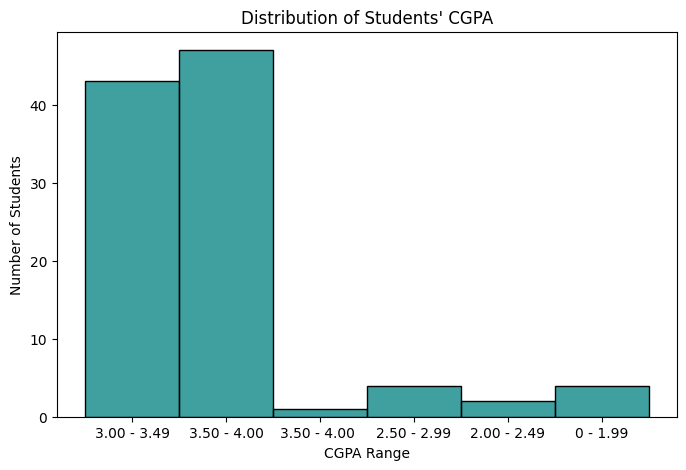

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/content/Student Mental health.csv')
# --- Exercise 1: Histogram of CGPA ---
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='What is your CGPA?', color='teal')
plt.title('Distribution of Students\' CGPA')
plt.xlabel('CGPA Range')
plt.ylabel('Number of Students')
plt.show()

/tmp/ipykernel_162/4097156792.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Choose your gender', y='Do you have Anxiety?', palette='pastel')


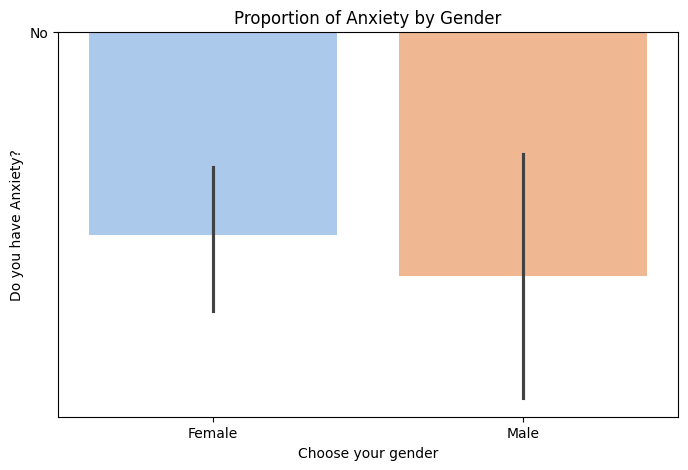

In [2]:
# --- Exercise 2: Anxiety by Gender ---
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Choose your gender', y='Do you have Anxiety?', palette='pastel')
plt.title('Proportion of Anxiety by Gender')
plt.show()

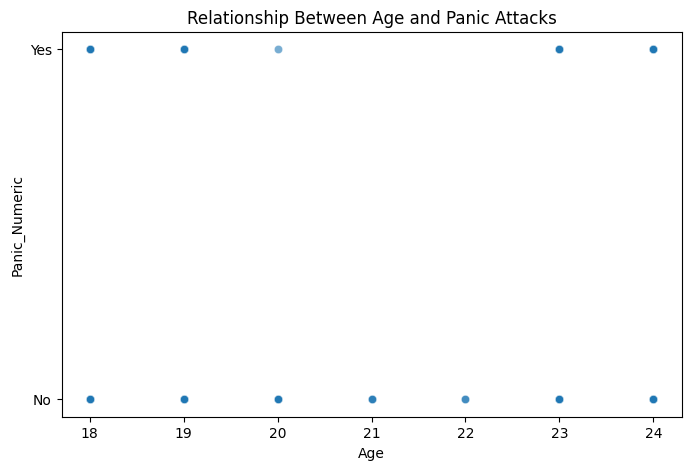

In [3]:
# --- Exercise 3: Age vs Panic Attacks ---
# Convert 'Yes'/'No' to 1/0 for the plot
df['Panic_Numeric'] = df['Do you have Panic attack?'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Age', y='Panic_Numeric', alpha=0.6)
plt.title('Relationship Between Age and Panic Attacks')
plt.yticks([0, 1], ['No', 'Yes'])
plt.show()

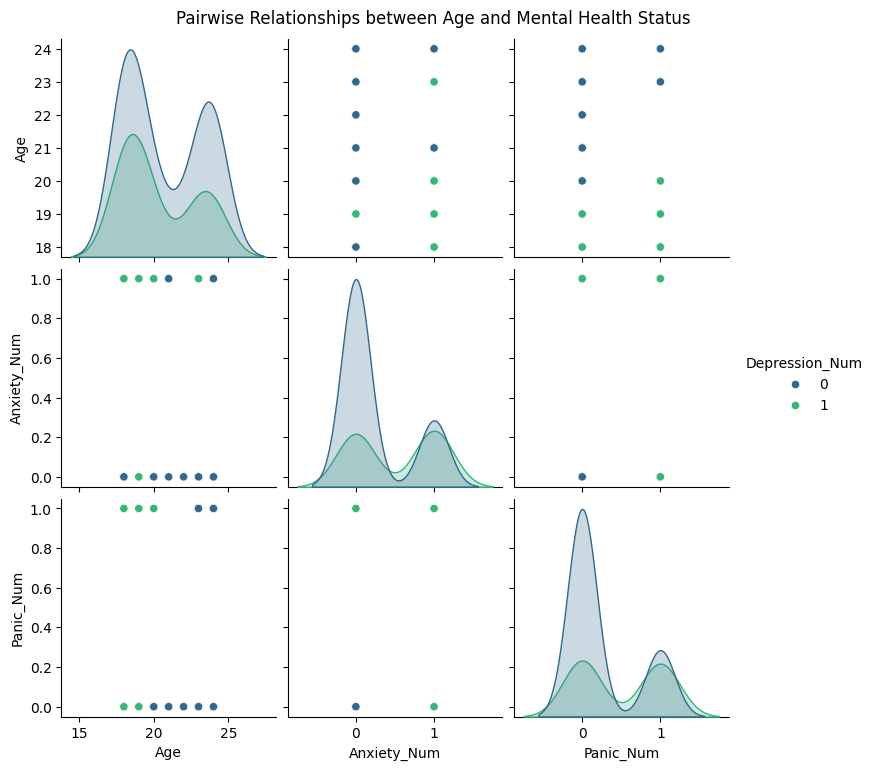

In [7]:
# --- Exercise 4: Pair Plot ---
mapping = {'Yes': 1, 'No': 0}

df['Depression_Num'] = df['Do you have Depression?'].map(mapping)
df['Anxiety_Num'] = df['Do you have Anxiety?'].map(mapping)
df['Panic_Num'] = df['Do you have Panic attack?'].map(mapping)


subset = df[['Age', 'Depression_Num', 'Anxiety_Num', 'Panic_Num']]


sns.pairplot(subset, hue='Depression_Num', palette='viridis', diag_kind='kde')

plt.suptitle('Pairwise Relationships between Age and Mental Health Status', y=1.02)
plt.show()

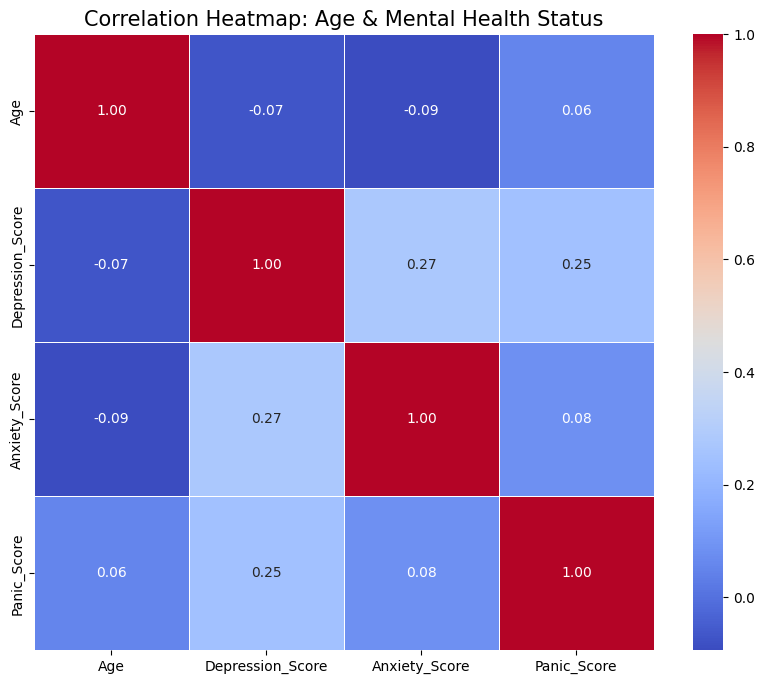

In [8]:
# --- Exercise 5: Correlation Heatmap ---
map_dict = {'Yes': 1, 'No': 0}

df['Depression_Score'] = df['Do you have Depression?'].map(map_dict)
df['Anxiety_Score'] = df['Do you have Anxiety?'].map(map_dict)
df['Panic_Score'] = df['Do you have Panic attack?'].map(map_dict)


cols_to_correlate = ['Age', 'Depression_Score', 'Anxiety_Score', 'Panic_Score']
corr_matrix = df[cols_to_correlate].corr()


plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap: Age & Mental Health Status', fontsize=15)
plt.show()

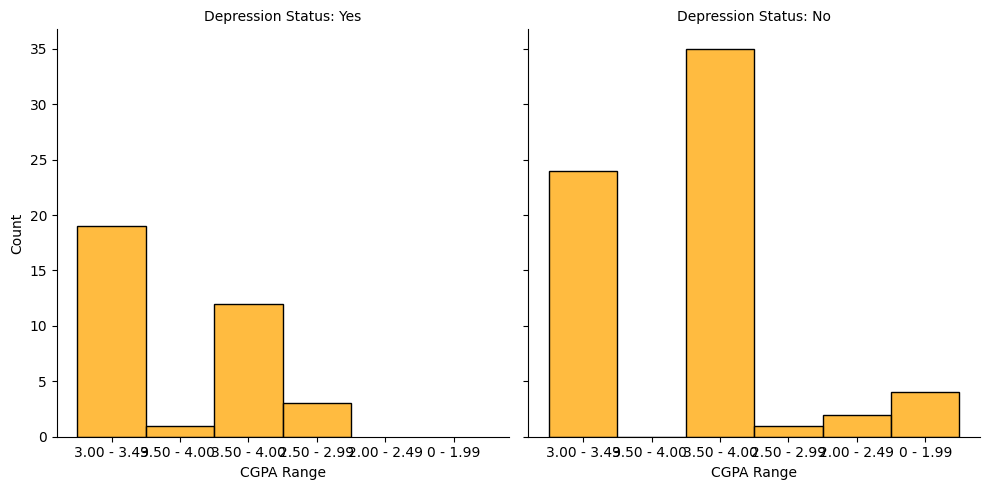

In [6]:
# --- Exercise 6: FacetGrid for CGPA ---
g = sns.FacetGrid(df, col='Do you have Depression?', height=5, aspect=1)
g.map(sns.histplot, 'What is your CGPA?', color='orange')
g.set_axis_labels('CGPA Range', 'Count')
g.set_titles(col_template='Depression Status: {col_name}')
plt.show()